
# FootVision ML Model

The model predicts:
- **H** = Home win
- **D** = Draw
- **A** = Away win


## 1. Import libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## 2. Load the datasets

In [14]:

# Read the CSV files
df = pd.read_csv("dataset1.csv")
elo_df = pd.read_csv("dataset2.csv")

print("Match dataset:", df.shape)
print("ELO dataset:", elo_df.shape)

df.head()


/tmp/ipykernel_1060/1191338027.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset1.csv")


Match dataset: (230557, 48)
ELO dataset: (245033, 4)


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Prepare the data

In [3]:

# Use 5-match form when available
form_h = "Form5Home" if "Form5Home" in df.columns else "Form3Home"
form_a = "Form5Away" if "Form5Away" in df.columns else "Form3Away"

# Keep only the columns needed by the ML model
df = df[["HomeElo", "AwayElo", form_h, form_a, "FTResult"]].copy()

# Remove missing values and invalid outcomes
df = df.dropna()
df = df[df["FTResult"].isin(["H", "D", "A"])]

print("Rows after cleaning:", len(df))
print("Home form column:", form_h)
print("Away form column:", form_a)


Rows after cleaning: 132004
Home form column: Form5Home
Away form column: Form5Away


## 4. Feature engineering

In [4]:

# Difference between home and away teams
df["elo_diff"] = df["HomeElo"] - df["AwayElo"]
df["form_diff"] = df[form_h] - df[form_a]

# Input features
X = df[["elo_diff", "form_diff"]]

# Target
y = df["FTResult"].map({
    "H": 0,
    "D": 1,
    "A": 2
})

print("Features:")
display(X.head())

print("Target:")
display(y.head())


Features:


,elo_diff,form_diff
0,99.77,0.0
1,72.38,0.0
2,-168.72,0.0
3,11.36,0.0
4,61.23,0.0


Target:


,FTResult
0,0
1,0
2,2
3,2
4,1


## 5. Outcome distribution

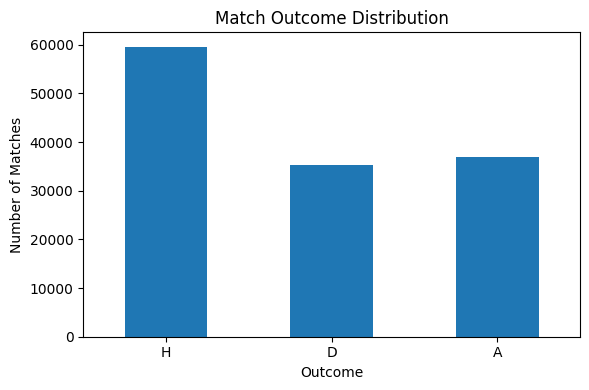

FTResult
H    59592
D    35367
A    37045
Name: count, dtype: int64


In [5]:

# Only one simple diagram for the dataset
outcomes = df["FTResult"].value_counts().reindex(["H", "D", "A"])

outcomes.plot(kind="bar", figsize=(6, 4))
plt.title("Match Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(outcomes)



## 6. Split the data

We keep 20% of the data for testing.

The test data is not used to train the model, so it gives a more useful estimate of performance on unseen matches.


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 105603
Testing samples : 26401


## 7. Standardize the features

In [7]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Train Logistic Regression

In [8]:

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Model training completed.")


Model training completed.


## 9. Evaluate the model

In [16]:

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}% \n")

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Home Win", "Draw", "Away Win"]
))


Test Accuracy: 49.62% 

Classification Report:
              precision    recall  f1-score   support

    Home Win       0.51      0.85      0.63     11919
        Draw       0.00      0.00      0.00      7073
    Away Win       0.46      0.41      0.43      7409

    accuracy                           0.50     26401
   macro avg       0.32      0.42      0.36     26401
weighted avg       0.36      0.50      0.41     26401



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10. Confusion matrix

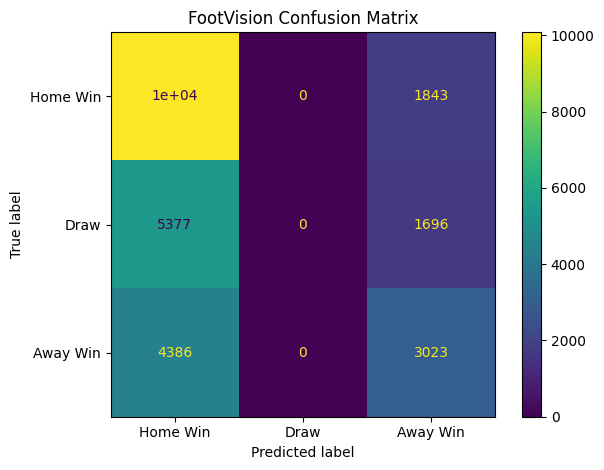

In [10]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Home Win", "Draw", "Away Win"]
)

disp.plot()
plt.title("FootVision Confusion Matrix")
plt.tight_layout()
plt.show()



## 11. Predict probabilities

`predict_proba()` gives the probability for all three outcomes.

The order follows the model classes:

`0 = Home Win`, `1 = Draw`, `2 = Away Win`


In [11]:

probabilities = model.predict_proba(X_test_scaled)

probability_df = pd.DataFrame(
    probabilities,
    columns=["Home Win %", "Draw %", "Away Win %"]
) * 100

probability_df.head()


,Home Win %,Draw %,Away Win %
0,59.103575,24.872053,16.024372
1,23.246075,28.374737,48.379189
2,36.792730,29.415651,33.791619
3,48.074047,27.881701,24.044252
4,37.639977,29.202412,33.157610


## 12. Save the trained model with Joblib

In [12]:

# Save the model and scaler
joblib.dump(model, "trained_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# Create the latest ELO lookup used by the Flask application
elo_df["date"] = pd.to_datetime(elo_df["date"], errors="coerce")

latest_elo = (
    elo_df.sort_values("date")
    .groupby("club")["elo"]
    .last()
    .to_dict()
)

joblib.dump(latest_elo, "elo_lookup.pkl")

print("Saved successfully:")
print("trained_model.pkl")
print("scaler.pkl")
print("elo_lookup.pkl")


Saved successfully:
trained_model.pkl
scaler.pkl
elo_lookup.pkl


## 13. Load the saved model

In [13]:

# Test that the saved files can be loaded
loaded_model = joblib.load("trained_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_elo = joblib.load("elo_lookup.pkl")

print("Model loaded successfully.")
print("Scaler loaded successfully.")
print("ELO lookup loaded successfully.")
print("Teams in ELO lookup:", len(loaded_elo))


Model loaded successfully.
Scaler loaded successfully.
ELO lookup loaded successfully.
Teams in ELO lookup: 895



# Final ML pipeline

**Dataset --> Cleaning --> Feature Engineering --> Train/Test Split --> Scaling --> Logistic Regression --> Evaluation --> Probability Prediction --> Joblib Model**

